# Linear Function Approximation

This notebook experiments with Q-learning using linear function approximation on CartPole. It compares the standard online update, which learns from each transition immediately, with replay-buffer Q-learning, which stores transitions and learns from sampled mini-batches. It also examines how a target network, implemented here as a separate linear function, can stabilize learning by reducing the moving-target problem.

Replay buffers and target networks are important techniques that will appear frequently in deep reinforcement learning. This experiment provides a simple setting for understanding how they change the learning process.

## Experiment Setup

This experiment compares three agents with linear function approximation on **CartPole-v1**:
1. **Online Q-learning (`QLearningAgentv1`)**: Learns from each transition immediately.
2. **Replay-buffer Q-learning (`QLearningAgentv2`)**: Uses an experience replay buffer to break correlation between consecutive transitions and learns from sampled mini-batches.
3. **Replay-buffer Q-learning with target network (`QLearningAgentv3`)**: Incorporates a periodically updated target network to stabilize training by decoupling the target values from frequent parameter updates (mitigating the moving target problem).

In [1]:
import sys
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

# Configure path to import agents and shared utils
NOTEBOOK_DIR = Path.cwd()
FUNCTION_APPROX_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "function-approximation"
AGENT_DIR = FUNCTION_APPROX_DIR / "algorithms" / "linear-function-approximation"

for path in [str(FUNCTION_APPROX_DIR), str(AGENT_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from agent import QLearningAgentv1
from agent_rb import QLearningAgentv2
from agent_rb_tn import QLearningAgentv3
from utils import plot_all_metrics, plot_metric


In [2]:
# Experiment Hyperparameters & Environment Configurations
GLOBAL_SEED = 17092026
np.random.seed(GLOBAL_SEED)
SEEDS = np.random.randint(0, 10000, size=10)

# Hyperparameters configs
LR = 0.001
GAMMA = 0.99
EPSILON = 1.0
EPSILON_DECAY = 0.998
BUFFER_SIZE = 5000
BATCH_SIZE = 32
T_TARGET_UPDATE = 500

ENV_CONFIGS = {
    "CartPole-v1": {"max_episodes": 3000},
}

AGENT_CLASSES = [
    "Online Q-learning",
    "Replay-buffer Q-learning",
    "Replay-buffer Q-learning with target network",
]

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
def build_agent(agent_name, env, seed):
    state_dim = int(np.prod(env.observation_space.shape))
    action_dim = env.action_space.n

    common_config = {
        "state_dim": state_dim,
        "action_dim": action_dim,
        "lr": LR,
        "gamma": GAMMA,
        "epsilon": EPSILON,
        "epsilon_decay": EPSILON_DECAY,
        "seed": seed,
    }

    if agent_name == "Online Q-learning":
        return QLearningAgentv1(**common_config)
    elif agent_name == "Replay-buffer Q-learning":
        return QLearningAgentv2(
            **common_config,
            batch_size=BATCH_SIZE,
            buffer_size=BUFFER_SIZE,
        )
    elif agent_name == "Replay-buffer Q-learning with target network":
        return QLearningAgentv3(
            **common_config,
            T_target_update=T_TARGET_UPDATE,
            batch_size=BATCH_SIZE,
            buffer_size=BUFFER_SIZE,
        )
    else:
        raise ValueError(f"Unknown agent name: {agent_name}")


def run_experiment(env_id, agent_name, seed, max_episodes):
    env = gym.make(env_id)
    agent = build_agent(agent_name, env, seed)
    history = agent.learn(env, max_episodes=max_episodes)
    env.close()
    return history


def run_all_experiments(env_configs=ENV_CONFIGS, seeds=SEEDS):
    results = {}
    for env_id, config in env_configs.items():
        results[env_id] = {}
        for agent_name in AGENT_CLASSES:
            results[env_id][agent_name] = []
            for seed in seeds:
                print(f"Running {agent_name} on {env_id} (seed={seed})...")
                history = run_experiment(
                    env_id=env_id,
                    agent_name=agent_name,
                    seed=int(seed),
                    max_episodes=config["max_episodes"],
                )
                results[env_id][agent_name].append({"seed": seed, "history": history})
    return results


## Run Experiments

Train all three agents on CartPole-v1 across multiple seeds.


In [4]:
ACTIVE_ENV_CONFIGS = {
    "CartPole-v1": ENV_CONFIGS["CartPole-v1"]
}

results = run_all_experiments(env_configs=ACTIVE_ENV_CONFIGS, seeds=SEEDS)
results.keys()


Running Online Q-learning on CartPole-v1 (seed=1490)...
Running Online Q-learning on CartPole-v1 (seed=2531)...
Running Online Q-learning on CartPole-v1 (seed=1401)...
Running Online Q-learning on CartPole-v1 (seed=9822)...
Running Online Q-learning on CartPole-v1 (seed=2074)...
Running Online Q-learning on CartPole-v1 (seed=5758)...
Running Online Q-learning on CartPole-v1 (seed=186)...
Running Online Q-learning on CartPole-v1 (seed=189)...
Running Online Q-learning on CartPole-v1 (seed=9070)...
Running Online Q-learning on CartPole-v1 (seed=2697)...
Running Replay-buffer Q-learning on CartPole-v1 (seed=1490)...
Running Replay-buffer Q-learning on CartPole-v1 (seed=2531)...
Running Replay-buffer Q-learning on CartPole-v1 (seed=1401)...
Running Replay-buffer Q-learning on CartPole-v1 (seed=9822)...
Running Replay-buffer Q-learning on CartPole-v1 (seed=2074)...
Running Replay-buffer Q-learning on CartPole-v1 (seed=5758)...
Running Replay-buffer Q-learning on CartPole-v1 (seed=186)...
Ru

dict_keys(['CartPole-v1'])

## Visualize Results

The multi-panel dashboard renders all metrics defined in `utils.METRIC_CONFIGS`:
- **Training Return**: Task performance with 95% confidence intervals across seeds.
- **Episode Length**: Steps per episode.
- **TD-Error Loss**: Mean squared TD error on a symlog scale.
- **Max Absolute TD Error**: Peak TD error magnitude per episode on a symlog scale to detect divergence/spikes.


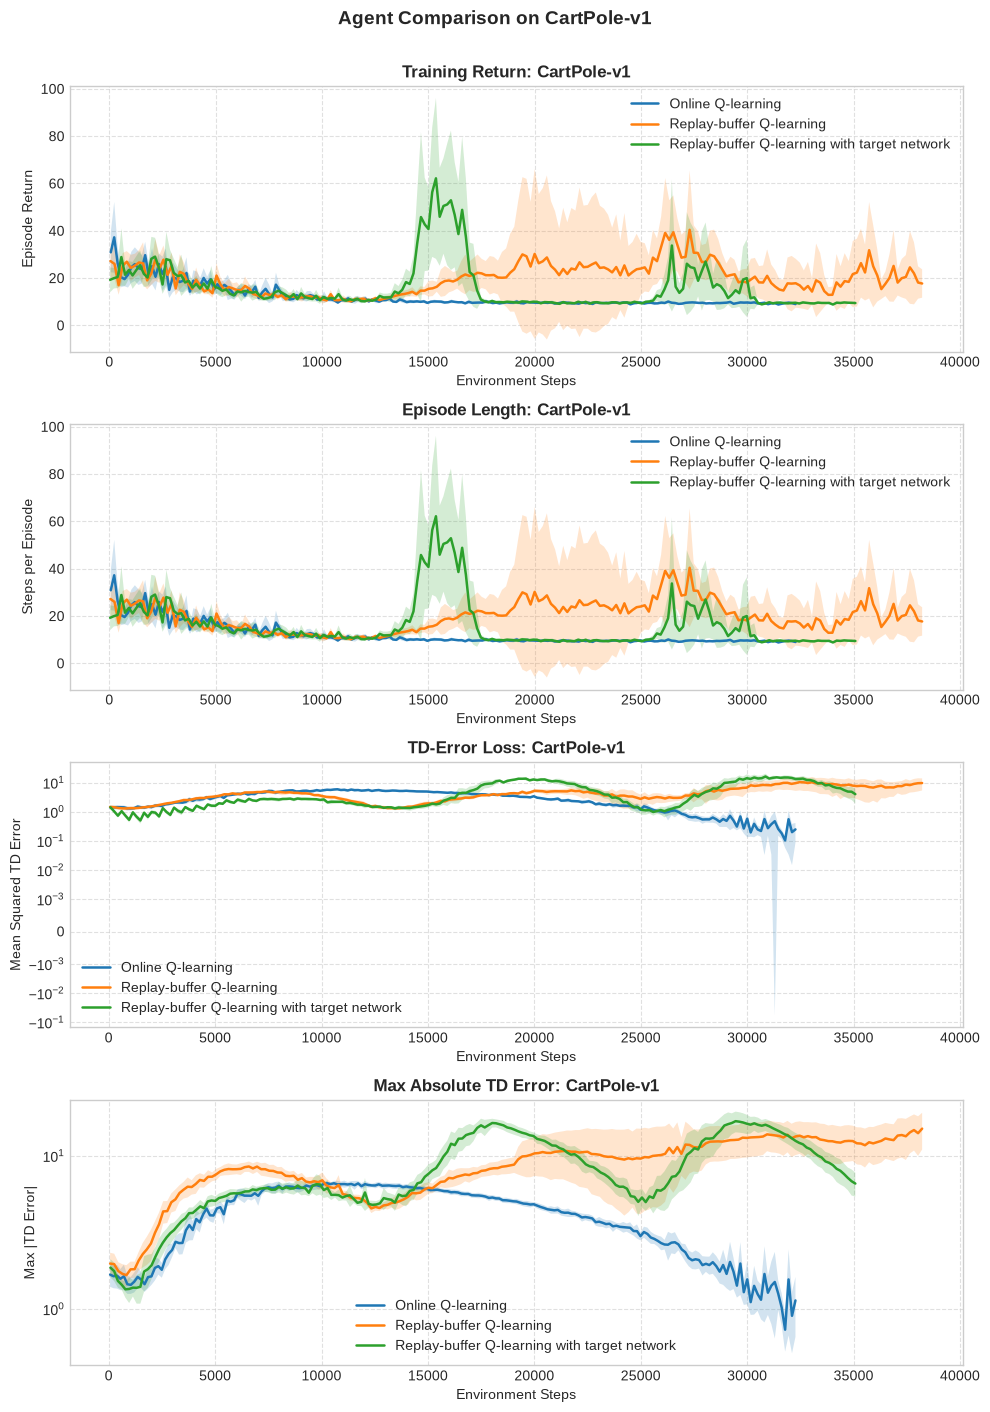

In [5]:
plot_all_metrics(results, env_id="CartPole-v1", x_key="cumulative_steps")
plt.show()


## Discussion

The main goal of this experiment was to understand how replay buffers and target networks affect Q-learning with function approximation. The results suggest that the replay-buffer agent maintains a higher return for longer, while the target-network agent can show temporary improvements and reduce the effect of rapidly changing targets. However, the training curves and TD-error plots are still noisy, so these techniques alone do not produce consistently strong performance here.

A key limitation is the linear function approximation. CartPole's observation is a four-dimensional vector containing the cart position, cart velocity, pole angle, and pole angular velocity. A single linear function can represent only relatively simple relationships between these values. It cannot easily capture the nonlinear interactions that are important for balancing the pole. In other words, replay and target networks can improve the learning process, but they cannot add representational capacity that the linear model does not have.

To learn richer relationships, we could use feature engineering methods such as tile coding, or move to nonlinear function approximation with a neural network. These approaches would give the agent a better representation of the state space and make the benefits of replay buffers and target networks more meaningful to evaluate.